# Black-Box 🤖
### Train a neural net on crypto prices and it 'predicts' tomorrow beautifully — until you ask it to predict a day it hasn't already seen.

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Overfit?: Confirmed](https://img.shields.io/badge/Overfit%3F-Confirmed-8b949e?style=flat-square)

This is the machine-learning cousin of [Crystal-Ball](../../22-crystal-ball/). There, a two-sided filter quietly leaked the future and manufactured a Sharpe-2 backtest out of a coin flip. Here the leak is subtler and far more common: an MLP with enough free parameters fit to the **same** data it is scored on will **memorise the noise** and report a gorgeous in-sample accuracy and Sharpe. The only honest test is **walk-forward**: fit on the past, predict the next block it has never seen, repeat. When we do that on real crypto, the edge collapses to ~0 and goes negative after costs. The black box was never predicting — it was remembering.

> 📓 **Plain-language layer.** The walk-forward protocol, the cost wall and the shuffled-label proof are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Charts below are generated by the code beside them; the core runs on a **synthetic** series, so the real crypto numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
warnings.filterwarnings("ignore")
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from black_box import data, strategy, costs, extension

# Offline synthetic control: a series with a weak NONLINEAR lagged signal (so an MLP CAN learn it) + a
# pure random-walk null (nothing to learn). The real BTC/ETH/LTC/XRP verdict is in ../docs/results.md.
NET = dict(hidden=(16, 8), max_iter=250)
WF = dict(min_train=400, step=200, **NET)
df, truth = data.synthetic_predictable(predictable_strength=0.015, n_bars=1200, seed=39)
df0, _ = data.synthetic_predictable(predictable_strength=0.0, n_bars=1200, seed=39)
close, close0 = df["close"], df0["close"]
print(f"synthetic control: {truth.n_bars} days, predictable_strength {truth.predictable_strength} (null=0)")


synthetic control: 1200 days, predictable_strength 0.015 (null=0)


## The answer first 🤖

| What we asked | The honest answer |
|---|---|
| Does the net 'predict' crypto in-sample? | 🟥 **Dazzlingly.** Fit-and-score on the same tape: in-sample Sharpe **5.38**, accuracy **0.664**. |
| Does it survive out-of-sample? | 🟥 **No.** Walk-forward OOS Sharpe **0.90** (accuracy **0.512**, barely a coin-flip); net of 10 bp **0.36**. |
| Is the in-sample number real skill? | ⚪ **No — it's overfitting.** The net memorises even **randomly shuffled** labels in-sample (train accuracy **0.664**, vs 0.5 chance). |

> Desk shorthand: **Signal `NONE` (OOS) · Tradability `MIRAGE` · Overfit? `CONFIRMED`** — a backtest mirage, caught in the act.

## 1 · The claim 📣

Neural-network crypto trading (Kakushadze-Serur §18.2):

1. **Features** — a small bank of causal, strictly-lagged predictors from past returns: the last few daily returns, trailing momentum, realised vol, a mean-reversion z-score.
2. **The net** — a small multilayer perceptron classifier predicting the **sign** of the next day's return.
3. **Trade** — go long the predicted-up days, short the predicted-down days.

The believer's case: crypto is young, retail-driven and inefficient, and a neural net can find nonlinear patterns a human or a linear model would miss. And in-sample, it certainly *looks* like it does.

in-sample Sharpe 5.9  accuracy 0.649


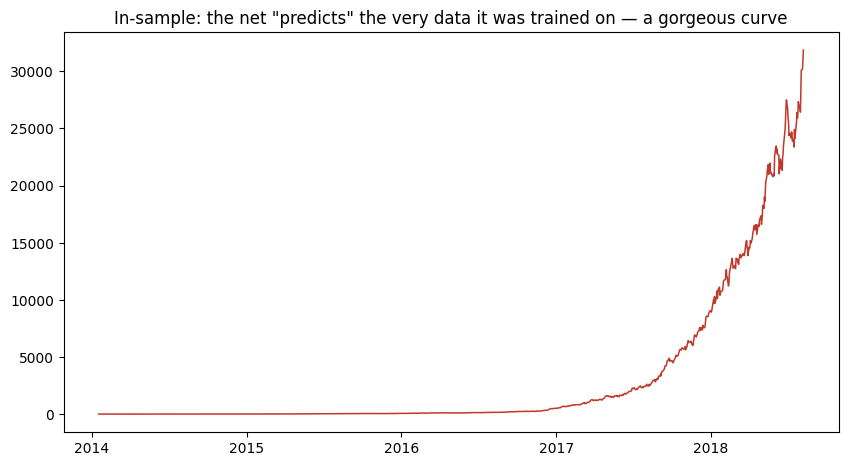

In [2]:
# Fit-and-predict on the SAME synthetic series (the trap), then trade the predicted sign.
pos_is = strategy.in_sample_predictions(close, **NET)
book_is = strategy.book_returns(close, pos_is, cost_bps=0.0)
eq = (1+book_is).cumprod()
fig, ax = plt.subplots(); ax.plot(eq.index, eq.values, color='#c0392b', lw=1.1)
ax.set_title('In-sample: the net "predicts" the very data it was trained on — a gorgeous curve')
s = strategy.summary(book_is); print(f"in-sample Sharpe {s['sharpe']:.1f}  accuracy {strategy.accuracy(close, pos_is):.3f}")

## 2 · So what? 💰

A model that genuinely called tomorrow's crypto direction even 55% of the time would be a money machine — crypto moves 3-5% a day. That is exactly why a beautiful in-sample backtest is so seductive, and so dangerous: it is the single most common way a quant fools themselves. The stakes here aren't a market truth — they're a *methodology* truth. If you cannot tell a real edge from a memorised one, every backtest you ever run is suspect.

## 3 · How we'd know 🔬

1. **Real?** Walk-forward out-of-sample Sharpe and accuracy — fit on the past, predict unseen days. (And a positive control: a synthetic series with a *real* weak signal the net *should* recover OOS.)
2. **Tradable?** Net OOS Sharpe at realistic crypto costs; break-even cost.
3. **Overfitting?** Shuffle the labels and re-fit in-sample — does the gorgeous fit survive *meaningless* targets?

**Mirage line:** walk-forward OOS accuracy ≈ 0.5 and OOS Sharpe ≈ 0 (negative after costs) — then the in-sample number was noise-fitting, not prediction.

## 4 · The teardown 🔧

### 4a · The machinery works where a signal is real (control vs null)

In [3]:
# Positive control: the net SHOULD recover the planted weak signal out-of-sample; the null has none.
for label, c in [('signal control', close), ('null (random walk)', close0)]:
    pos = strategy.walk_forward_predictions(c, **WF)
    s = strategy.summary(strategy.book_returns(c, pos, cost_bps=0.0))
    print(f"{label:20} walk-forward OOS Sharpe {s['sharpe']:+6.2f}  accuracy {strategy.accuracy(c, pos):.3f}")

signal control       walk-forward OOS Sharpe  +2.66  accuracy 0.563


null (random walk)   walk-forward OOS Sharpe  -0.67  accuracy 0.474


### 4b · On real crypto — gorgeous in-sample, gone out-of-sample
BTC/ETH/LTC/XRP, daily ([`../docs/results.md`](../docs/results.md)):

- **In-sample** (the trap): Sharpe **5.38**, accuracy **0.664** — looks like a money printer.
- **Walk-forward OOS**: Sharpe **0.90**, accuracy **0.512** — a coin flip. Net of 10 bp: **0.36**.
- Across coins the OOS Sharpe is small and mixed: BTC +0.90, ETH +0.41, LTC +0.34, XRP +0.32 — no consistent edge.

Real tape (../docs/results.md, BTC flagship):
  in-sample      Sharpe 5.38  accuracy 0.664
  walk-forward OOS Sharpe 0.90  accuracy 0.512  net@10bp 0.36
  break-even 16.68 bp   turnover 0.91/day


Text(0.5, 1.0, 'In-sample vs out-of-sample equity (synthetic control)')

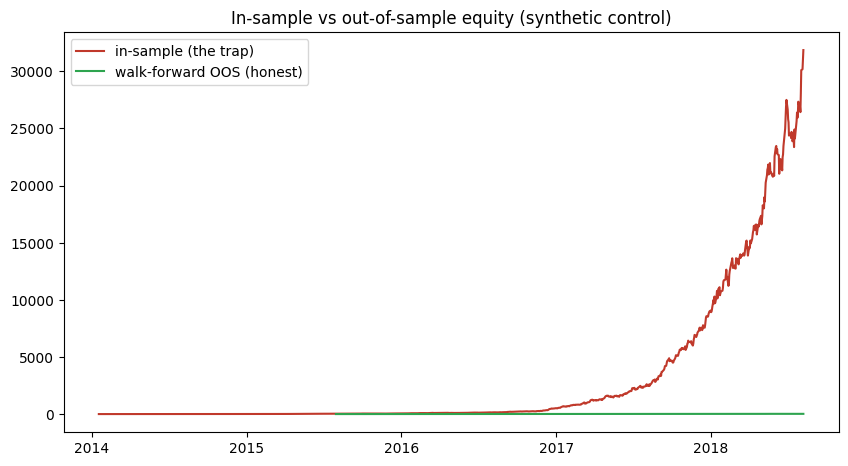

In [4]:
print('Real tape (../docs/results.md, BTC flagship):')
print('  in-sample      Sharpe 5.38  accuracy 0.664')
print('  walk-forward OOS Sharpe 0.90  accuracy 0.512  net@10bp 0.36')
print('  break-even 16.68 bp   turnover 0.91/day')
# The collapse, drawn live on the synthetic where there IS a real signal to find:
pos_is  = strategy.in_sample_predictions(close, **NET)
pos_oos = strategy.walk_forward_predictions(close, **WF)
fig, ax = plt.subplots()
ax.plot((1+strategy.book_returns(close, pos_is, 0.0)).cumprod(), color='#c0392b', label='in-sample (the trap)')
ax.plot((1+strategy.book_returns(close, pos_oos, 0.0)).cumprod(), color='#2ea44f', label='walk-forward OOS (honest)')
ax.legend(); ax.set_title('In-sample vs out-of-sample equity (synthetic control)')

## 5 · The verdict 🧾

- **Signal `NONE` (out-of-sample)** — walk-forward OOS accuracy 0.512 (≈ coin-flip), Sharpe 0.90.
- **Tradability `MIRAGE`** — net of 10 bp 0.36; there is no gross OOS edge for costs to even erode.
- **Overfit `CONFIRMED`** — the net fits *shuffled* labels in-sample (train accuracy 0.664 ≈ 0.67).

> **The in-sample Sharpe was a mirage of memorisation.** The honest, walk-forward number is the only one a live trader could have earned — and it is nothing.

## 6 · Could you trade it? 💸

- **No.** The only number you can actually trade on is the walk-forward one, and it is a coin-flip before costs and negative after.
- **The trap is the lesson.** Anyone who reports the in-sample Sharpe — or who tunes the architecture / features against the test set — is selling you the mirage. With enough trials, *something* will look great in-sample by pure chance (Bailey-Borwein-López de Prado-Zhu 2014).
- **Costs finish it.** Even the noisy OOS book flips position often; at 10-20 bp round-trip (realistic for crypto) any sliver of OOS Sharpe is gone.

## 7 · Going further 🚪

### Worked complement — the shuffled-label control ([`../docs/extension.md`](../docs/extension.md))
The cleanest proof the in-sample number is noise: randomly **shuffle the targets** and re-fit. If the gorgeous in-sample fit survives meaningless labels, it was never measuring skill:

- True-label in-sample train accuracy ≈ **0.664**; shuffled-label ≈ **0.67** — essentially the same. The net memorises whatever it is handed.

### Other forks
- **Honest model selection** — purged, embargoed cross-validation (López de Prado 2018).
- **Deflated Sharpe** — correct the in-sample Sharpe for the number of configurations tried.
- **Richer features / other coins** — does *any* honest OOS edge appear? (Our pre-registration says: probably not, on daily direction.)

PRs welcome — try purged CV, a deflated Sharpe, or a different feature bank and report the *walk-forward* number, not the in-sample one.